In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch import Tensor
from beartype import beartype
from jaxtyping import jaxtyped, Float, Int
from scipy.stats import spearmanr, norm

from ram.dataset.morphology import sample_morph
from ram.model import Model
from ram.dataset.workspace import sample_poses_in_reach, ball_approximation
from ram.dataset.kinematics import inverse_kinematics,transformation_matrix
from paper_archive.utils import get_plt_colour
from tqdm import tqdm

In [2]:
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})

In [3]:
@jaxtyped(typechecker=beartype)
def pca(data: Float[Tensor, "batch dim"],
        standardise: bool = True,
        n_components: int = None,
        p_variance: float = None,
        factor_loading: bool = False) \
        -> Float[Tensor, "batch new_dim"]:
    """
    Perform Principial Component Analysis (PCA) on the data.
    Args:
        data: The input data to be PCA-ed.
        standardise: Whether to standardise the data before PCA.
        n_components: The number of principal components to keep. If None, all components are kept.
        p_variance: The proportion of variance to keep. If None, all variance is kept. Should be called with n_components=None and will otherwise take precendence.
        factor_loading: Whether to multiply the results by the eigenvalues.

    Returns:
        The PCA-ed data.
    """
    if standardise:
        data = (data - torch.mean(data, dim=0)) / (torch.std(data, dim=0))
    else:
        data = data - torch.mean(data, dim=0)
    u, s, vh = torch.linalg.svd(data, full_matrices=False)
    eigenvalues = (s ** 2) / (data.shape[0] - 1)

    k = s.shape[0]
    if p_variance:
        k = int(torch.where(torch.cumsum(eigenvalues, dim=0) / torch.sum(eigenvalues) >= p_variance)[0][0].item()) + 1
    elif n_components:
        k = n_components

    data = data @ vh[:k, :].T

    if factor_loading:
        data = data * torch.sqrt(eigenvalues[:k])

    return data

In [4]:
@jaxtyped(typechecker=beartype)
def correlation_profile(data: Float[Tensor, "batch dim"], attribute: Float[Tensor, "batch"]) \
        -> Float[Tensor, "dim 4"]:
    """
    Calculate the correlation coefficients for every data component vs a scalar.

    Args:
        data: The data to be correlated.
        attribute: The scalar property to be correlated against.
    Returns:
        Spearman correlation coefficients, Spearman CI bounds, and p-values.
    """
    spearman_result = spearmanr(data.cpu(), attribute.unsqueeze(1).cpu(), axis=0)
    spearman = torch.from_numpy(spearman_result.statistic[-1, :-1]).to(data.device)
    p_values = torch.from_numpy(spearman_result.pvalue[-1, :-1]).to(data.device)

    z      = torch.arctanh(spearman.clamp(-0.9999, 0.9999))
    se     = 1.0 / torch.sqrt(torch.tensor(data.shape[0] - 3, dtype=torch.float32, device=data.device))
    z_crit = torch.tensor(norm.ppf(1 - (1 - 0.95) / 2), dtype=torch.float32, device=data.device)
    ci_low  = torch.tanh(z - z_crit * se)
    ci_high = torch.tanh(z + z_crit * se)

    return torch.stack([spearman, ci_low, ci_high, p_values], dim=1)

In [70]:
@jaxtyped(typechecker=beartype)
def scatter_matrix(data: Float[Tensor, "batch 1"],
                   attribute: Float[Tensor, "batch"],
                   axis_numbers: Int[Tensor, "1"],
                   attribute_name: str,
                   coefficients: Float[Tensor, "1 4"]):
    """
    Create a 1x3 scatter matrix plot for correlations.

    Args:
        data: The data to be correlated.
        attribute: The scalar property to be correlated against.
        axis_numbers: The numbers of the principal components to be plotted.
        attribute_name: The name of the scalar property to be plotted.
        coefficients: The correlation coefficients to be printed in an inlet.
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    ax.scatter(attribute.cpu(), data[:, 0].cpu(), color=get_plt_colour(0), alpha=0.5, s=30)
    ax.set_ylabel(rf"PC {axis_numbers[0] + 1}")
    ax.set_xlabel(attribute_name)
    #ax.set_xticks([5,6,7])
    ax.grid(True, linestyle='--', alpha=0.5)

    c = torch.round(coefficients[:, :3] * 100, decimals=1)
    p = coefficients[0, 3].item()

    print(rf"PC{axis_numbers[0].item() + 1}:  SCC ${c[0, 0]:.1f}$\% $[{c[0, 1]:+.1f}$\%, ${c[0, 2]:+.1f}$\%], $p={p:.3f}$")
    plt.savefig(f"exploration_{attribute_name}.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"exploration_std.pdf", format="pdf", bbox_inches="tight")

In [6]:
@jaxtyped(typechecker=beartype)
def scalar_individual(data: Float[Tensor, "batch dim"],
                      attribute: Float[Tensor, "batch"],
                      attribute_name: str):
    """
    Investigate the correlation between a scalar property individual to a robot and the latent space.

    Args:
        data: Latent embedding of robots.
        attribute: Scalar property of robots.
        attribute_name: Name of the scalar property.
    """
    coefficients = correlation_profile(data, attribute)
    indices = torch.argsort(coefficients[:, 0].abs(), descending=True)

    data = data[:, indices][:, :1]
    axis_numbers = indices[:1]
    coefficients = coefficients[indices, :][:1, :]
    scatter_matrix(data, attribute, axis_numbers, attribute_name, coefficients)

In [7]:
@jaxtyped(typechecker=beartype)
def mantel_test(similarity_a: Float[Tensor, "batch batch"],
                similarity_b: Float[Tensor, "batch batch"],
                n_bootstrap: int = 999,
                n_permutations: int = 999) -> tuple[float, float, float, float]:
    """
    Mantel test: correlates the upper triangles of two symmetric matrices
    and estimates significance via permutation of rows/columns.

    Args:
        similarity_a: First symmetric matrix (similarity or distance).
        similarity_b: Second symmetric matrix (similarity or distance).
        n_bootstrap: Number of bootstrap samples for the CI.
        n_permutations: Number of permutations for the p-value estimate.
    Returns:
        Spearman correlation coefficient, Spearman CI bounds, and p-value.
    """
    idx = torch.triu_indices(similarity_a.shape[0], similarity_a.shape[0], offset=1)
    v_a = similarity_a[idx[0], idx[1]].cpu()
    v_b = similarity_b[idx[0], idx[1]].cpu()
    spearman = spearmanr(v_a, v_b).statistic

    bootstrap_r = torch.empty(n_bootstrap, device=similarity_a.device)
    for i in range(n_bootstrap):
        sample = torch.randint(0, similarity_a.shape[0], (similarity_a.shape[0],))
        a_boot = similarity_a[sample][:, sample]
        b_boot = similarity_b[sample][:, sample]
        bootstrap_r[i] = spearmanr(
            a_boot[idx[0], idx[1]].cpu(),
            b_boot[idx[0], idx[1]].cpu()
        ).statistic
    alpha = (1 - 0.95) / 2
    ci_low, ci_high = torch.quantile(bootstrap_r, torch.tensor([alpha, 1 - alpha], device=bootstrap_r.device))

    count = 0
    for _ in range(n_permutations):
        perm = torch.randperm(similarity_a.shape[0])
        b_perm = similarity_b[perm][:, perm]
        if spearmanr(v_a, b_perm[idx[0], idx[1]].cpu()).statistic >= spearman:
            count += 1
    p_value = (count + 1) / (n_permutations + 1)
    return spearman, ci_low.item(), ci_high.item(), p_value

In [72]:
@jaxtyped(typechecker=beartype)
def scalar_pairwise(similarity_latent: Float[Tensor, "batch batch"],
                    similarity_workspace: Float[Tensor, "batch batch"],
                    latent_name: str,
                    y_name: str,
                    n_bootstrap: int = 999):
    """
    Investigate the correlation between pairwise latent and workspace similarities
    via a Mantel test and scatter plot.

    Args:
        similarity_latent: Pairwise latent similarity matrix.
        similarity_workspace: Pairwise workspace similarity matrix.
        latent_name: Label for the latent similarity axis.
        y_name: Label for the workspace similarity axis.
        n_bootstrap: Number of bootstrap samples for the CI.
    """
    r, ci_low, ci_high, p_value = mantel_test(similarity_latent, similarity_workspace, n_bootstrap)

    idx = torch.triu_indices(similarity_latent.shape[0], similarity_latent.shape[0], offset=1)
    v_latent    = similarity_latent[idx[0], idx[1]].cpu()
    v_workspace = similarity_workspace[idx[0], idx[1]].cpu()

    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    ax.scatter(v_latent, v_workspace,
               color=get_plt_colour(0), alpha=0.5, s=30)
    ax.set_xlabel(latent_name)
    ax.set_ylabel(y_name)
    ax.grid(True, linestyle="--", alpha=0.5)
    print(rf"SCC ${r*100:+.1f}$\% $[{ci_low*100:+.1f}$\%, ${ci_high*100:+.1f}$\%], "
          rf"$p={p_value:.3f}$")
    plt.savefig(f"exploration_{y_name}.pdf", format="pdf", bbox_inches="tight")

In [9]:
torch.manual_seed(0)
device = torch.device("cuda")

In [10]:
model = Model.from_id(142).to(device)

In [11]:
morphs = torch.cat([
    torch.cat([sample_morph(1000, 5, False, device=device), torch.zeros(1000, 2, 3, device=device)], dim=1),
    torch.cat([sample_morph(1000, 6, False, device=device), torch.zeros(1000, 1, 3, device=device)], dim=1),
    sample_morph(1000, 7, False, device=device)
])
latent = model.encoder(morphs)[1][0][-1].detach()

In [12]:
full_latent = pca(latent)

In [13]:
centre, radius = ball_approximation(morphs)

PC1:  SCC $85.8$\% $[+84.9$\%, $+86.7$\%], $p=0.000$


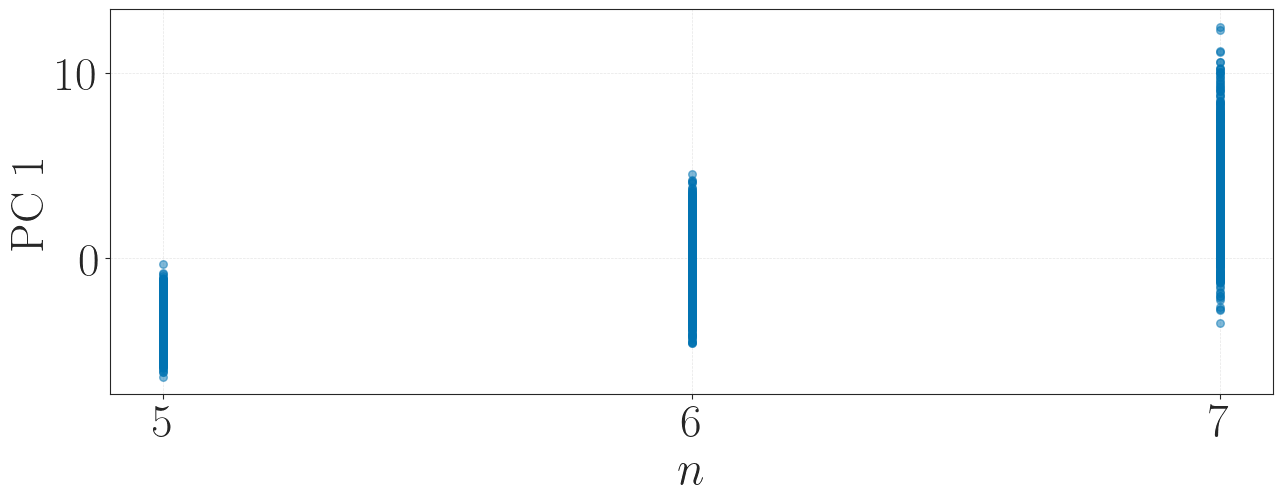

In [71]:
scalar_individual(full_latent, torch.cat([
    torch.full((1000,), 5),
    torch.full((1000,), 6),
    torch.full((1000,), 7),
]).to(device).float(), "$n$")

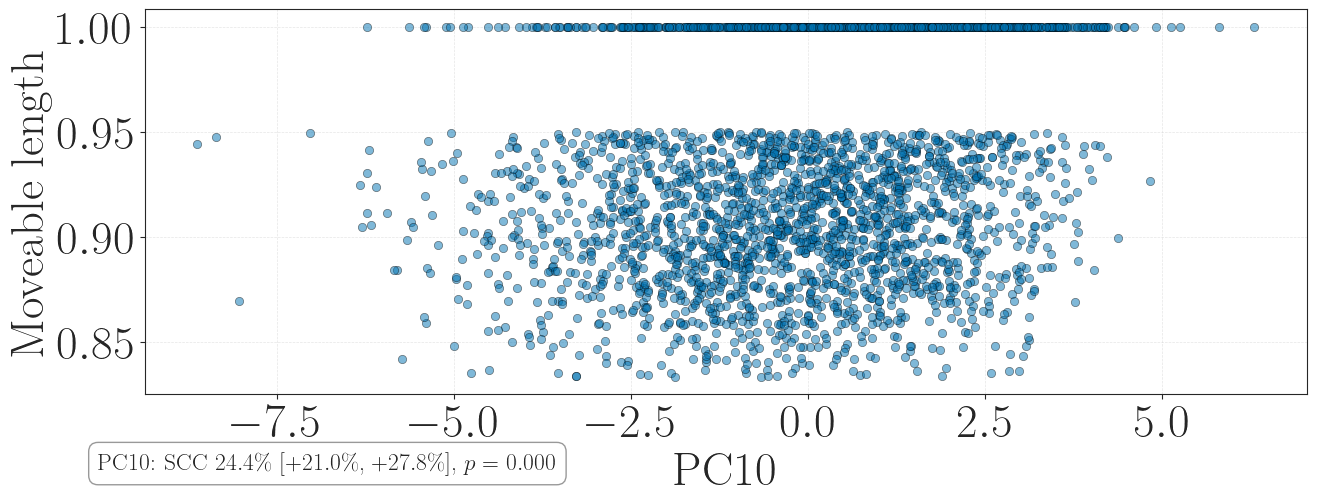

In [15]:
scalar_individual(full_latent, radius, "Moveable length")

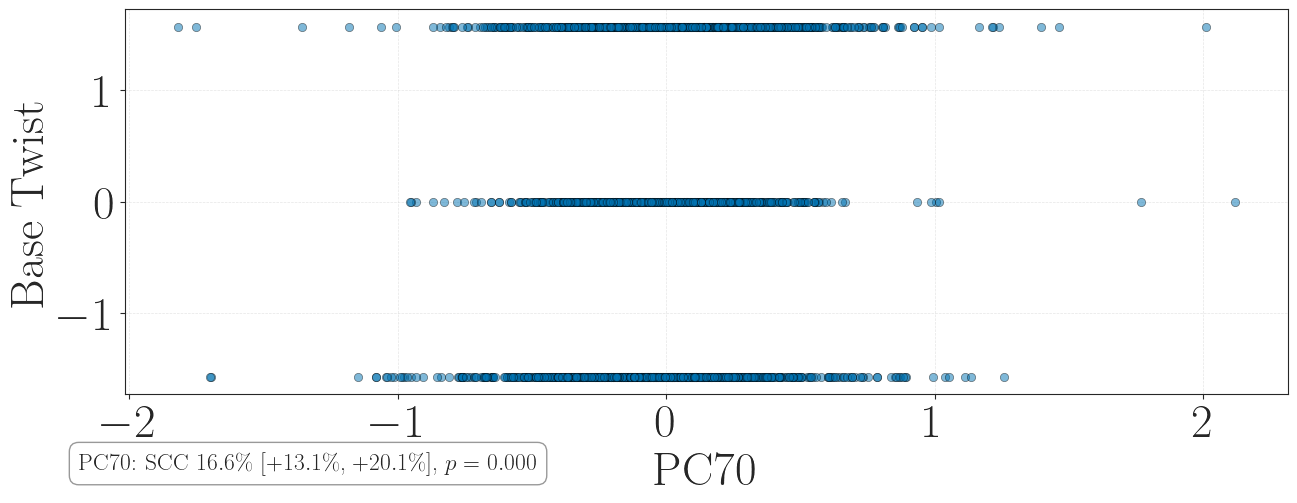

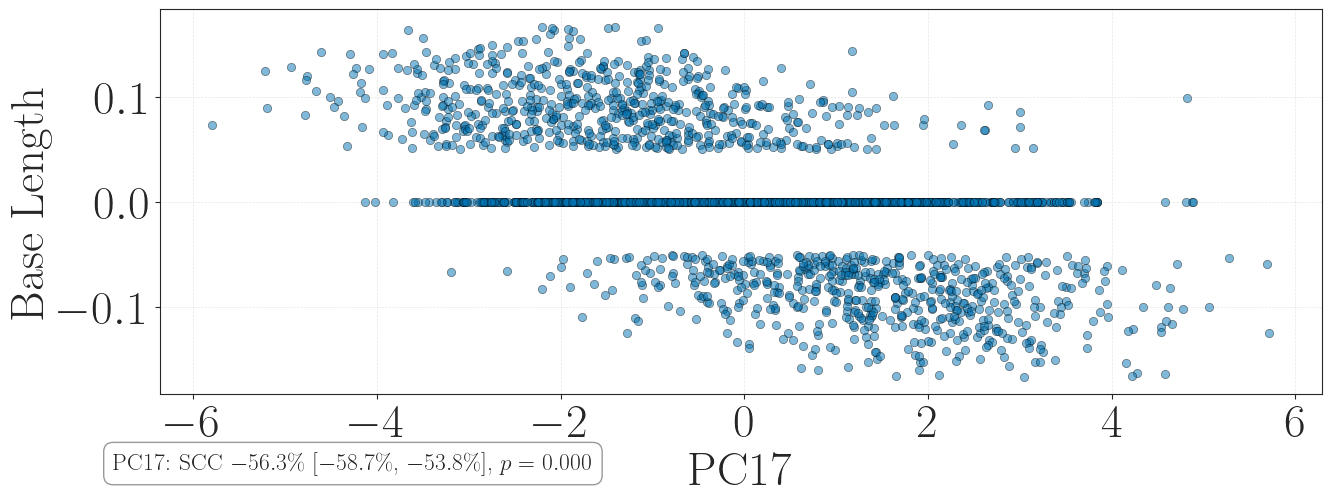

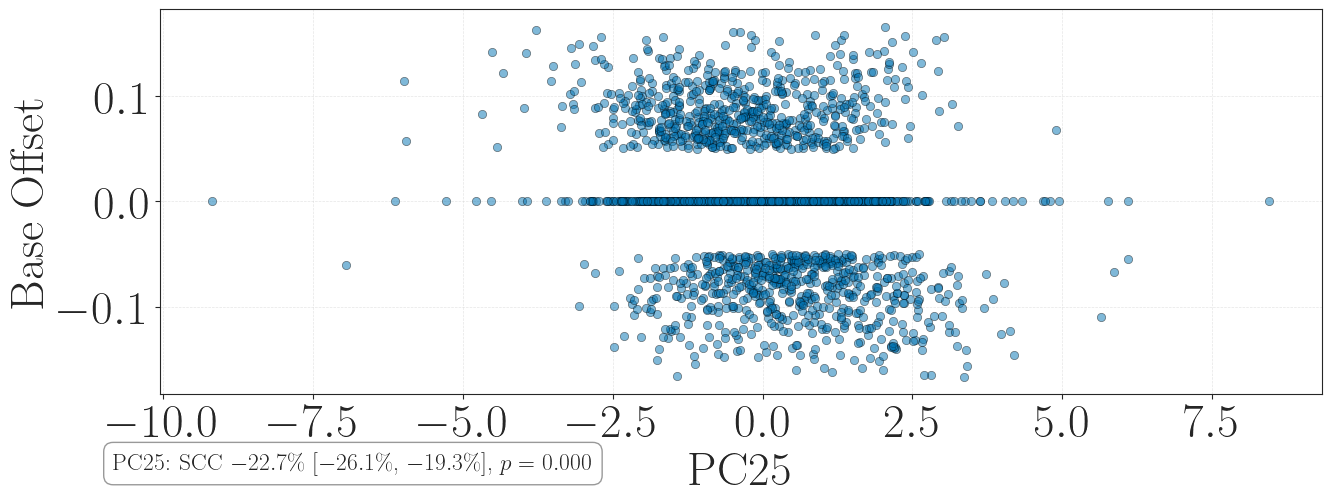

In [16]:
scalar_individual(full_latent, morphs[:, 0, 0], "Base Twist")
scalar_individual(full_latent, morphs[:, 0, 1], "Base Length")
scalar_individual(full_latent, morphs[:, 0, 2], "Base Offset")

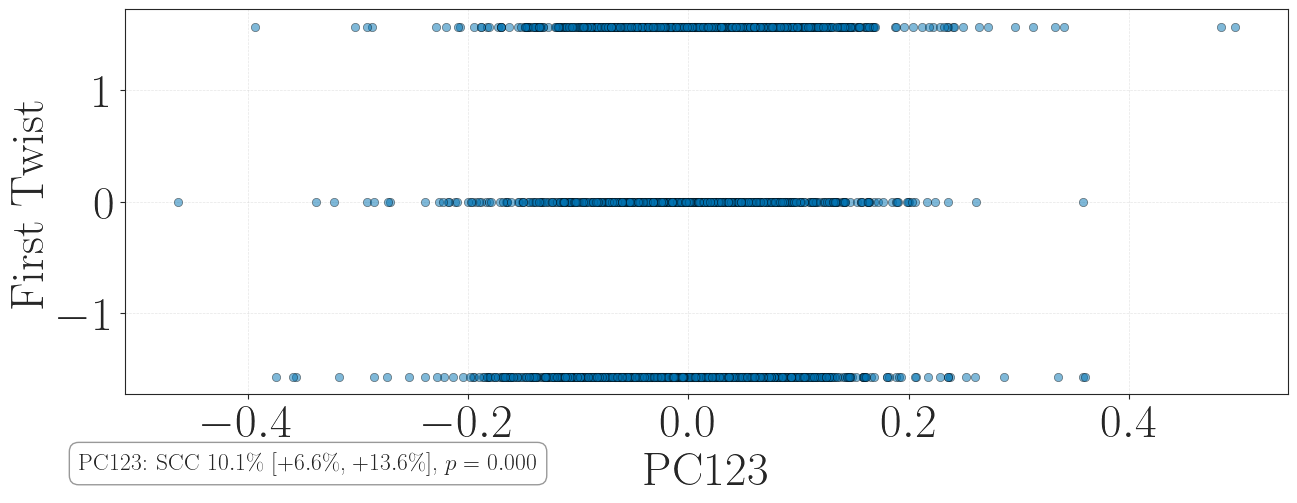

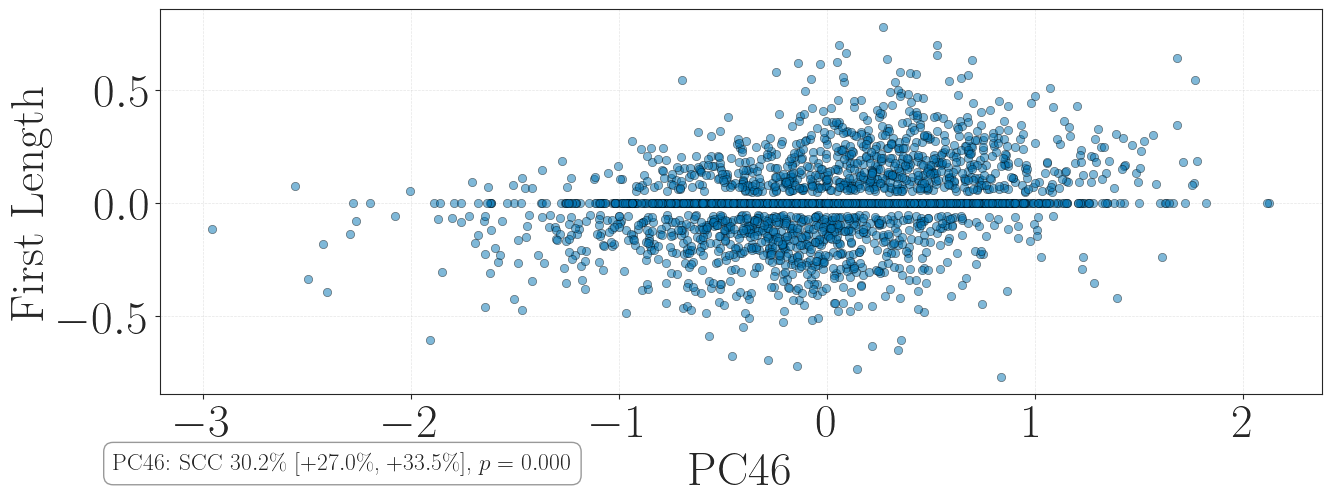

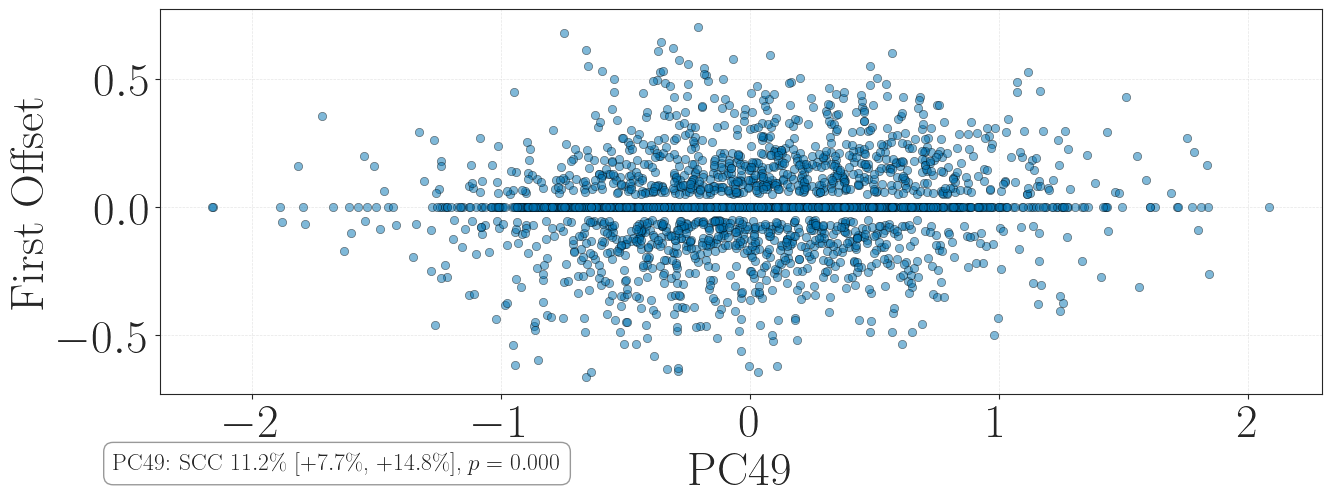

In [17]:
scalar_individual(full_latent, morphs[:, 1, 0], "First Twist")
scalar_individual(full_latent, morphs[:, 1, 1], "First Length")
scalar_individual(full_latent, morphs[:, 1, 2], "First Offset")

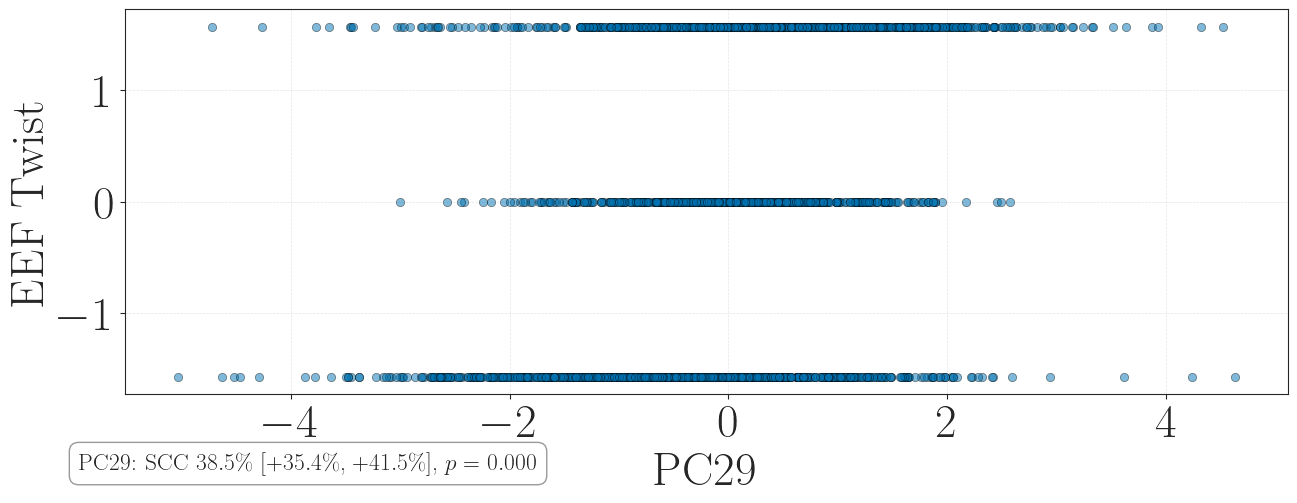

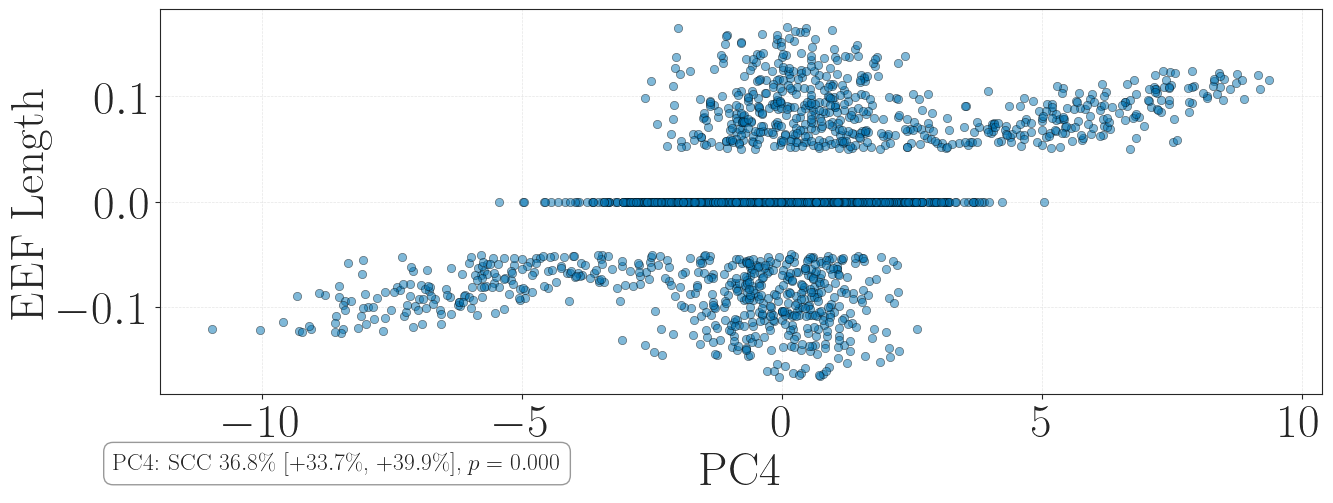

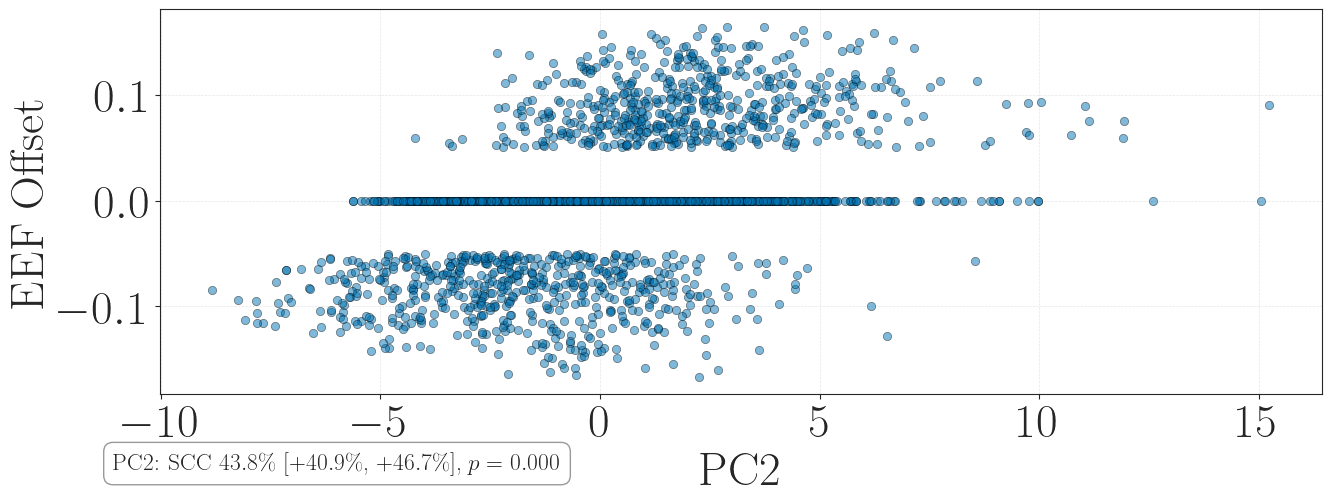

In [18]:
eef_idx = torch.cat([
    torch.full((1000,), 5),
    torch.full((1000,), 6),
    torch.full((1000,), 7),
]).to(device)
scalar_individual(full_latent, morphs[torch.arange(3000), eef_idx, 0], "EEF Twist")
scalar_individual(full_latent, morphs[torch.arange(3000), eef_idx, 1], "EEF Length")
scalar_individual(full_latent, morphs[torch.arange(3000), eef_idx, 2], "EEF Offset")

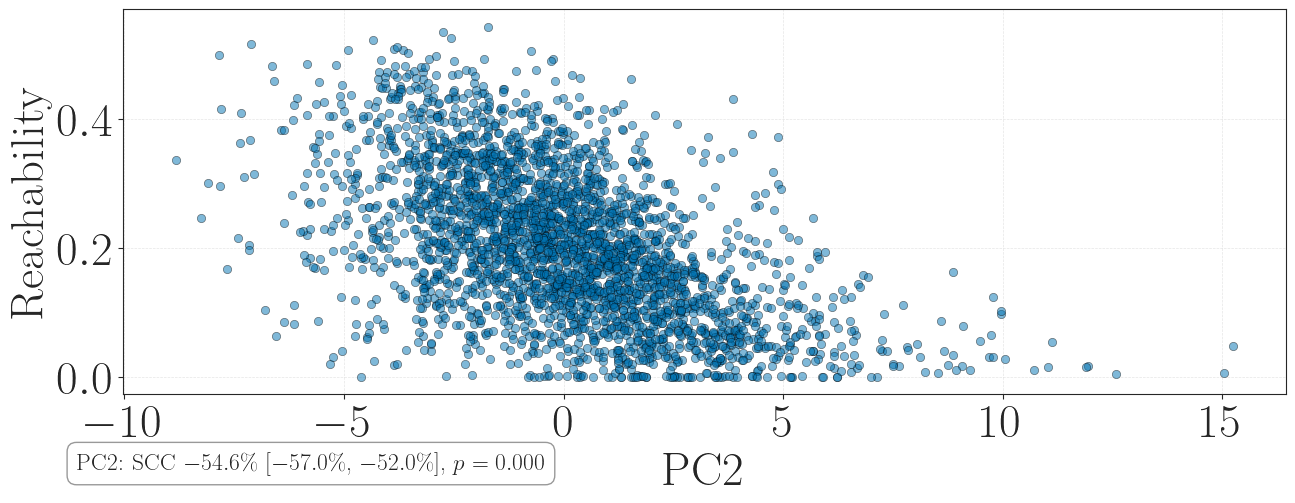

In [19]:
reachability = torch.tensor([(inverse_kinematics(m, sample_poses_in_reach(1000, m))[-1] != -1).sum() / 1000 for m in morphs])
scalar_individual(full_latent, reachability, "Reachability")

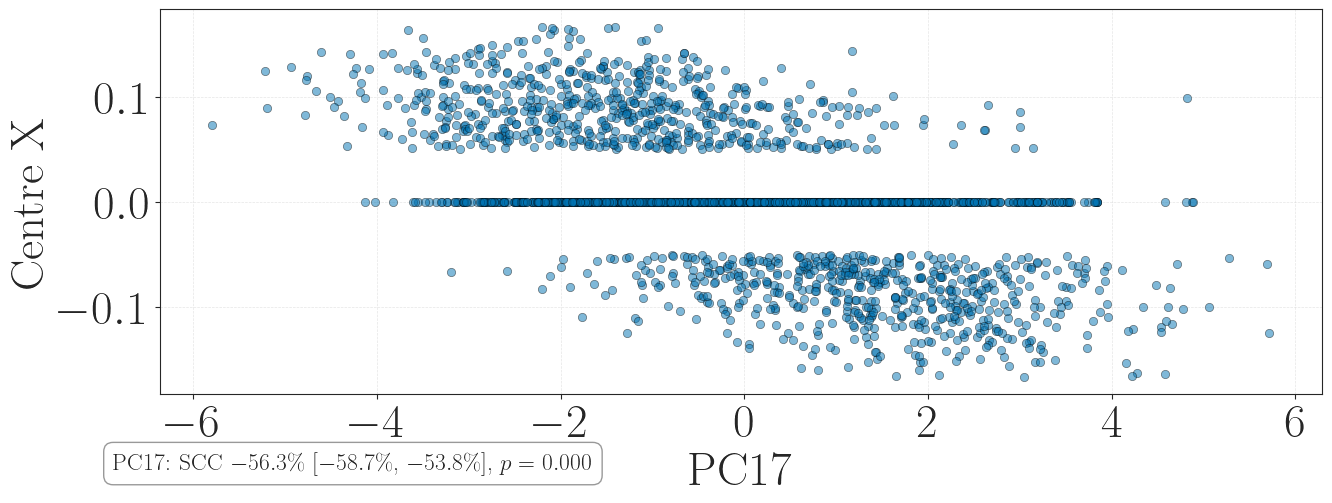

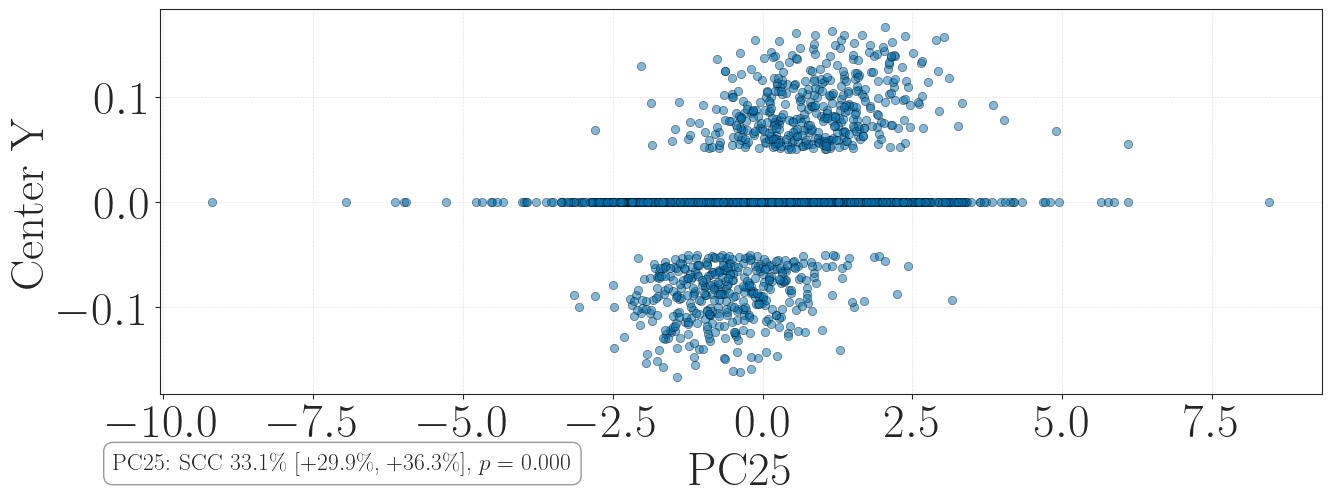

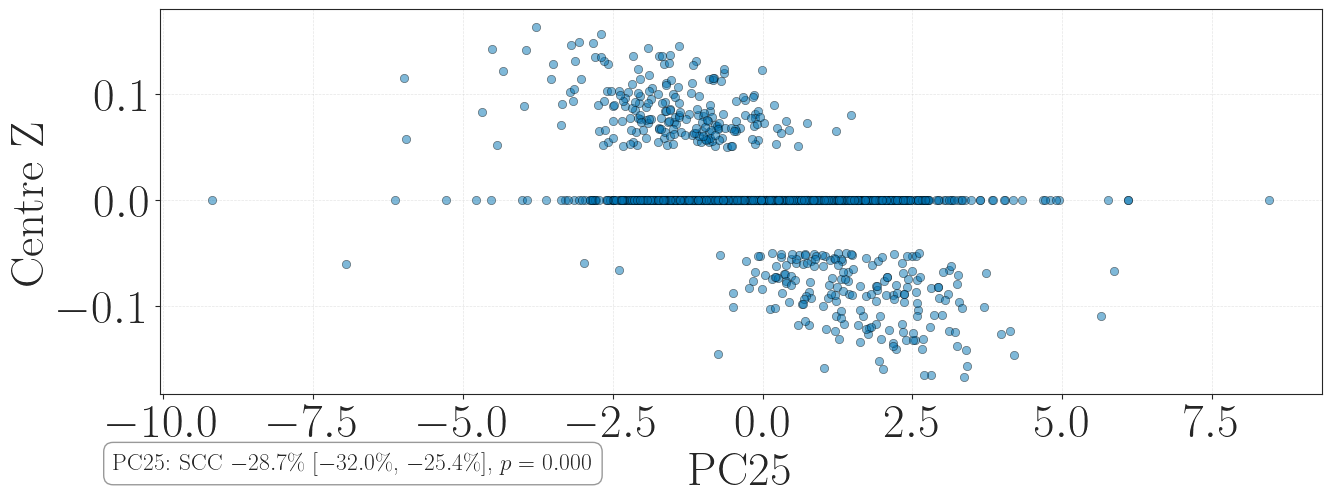

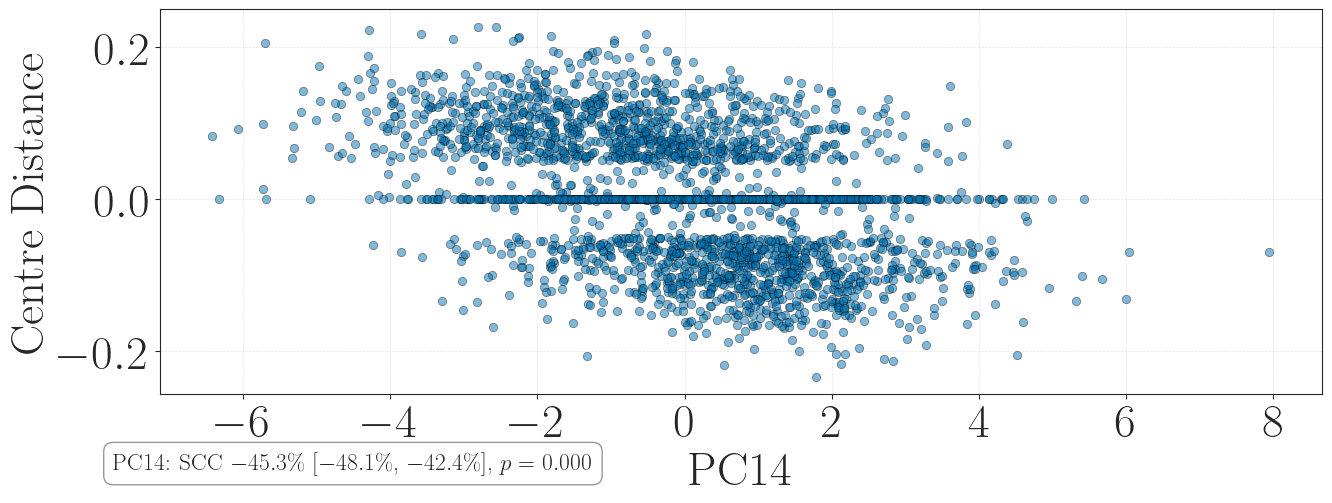

In [20]:
scalar_individual(full_latent, centre[:, 0], "Centre X")
scalar_individual(full_latent, centre[:, 1], "Center Y")
scalar_individual(full_latent, centre[:, 2], "Centre Z")
scalar_individual(full_latent, centre.sum(dim=1), "Centre Distance")

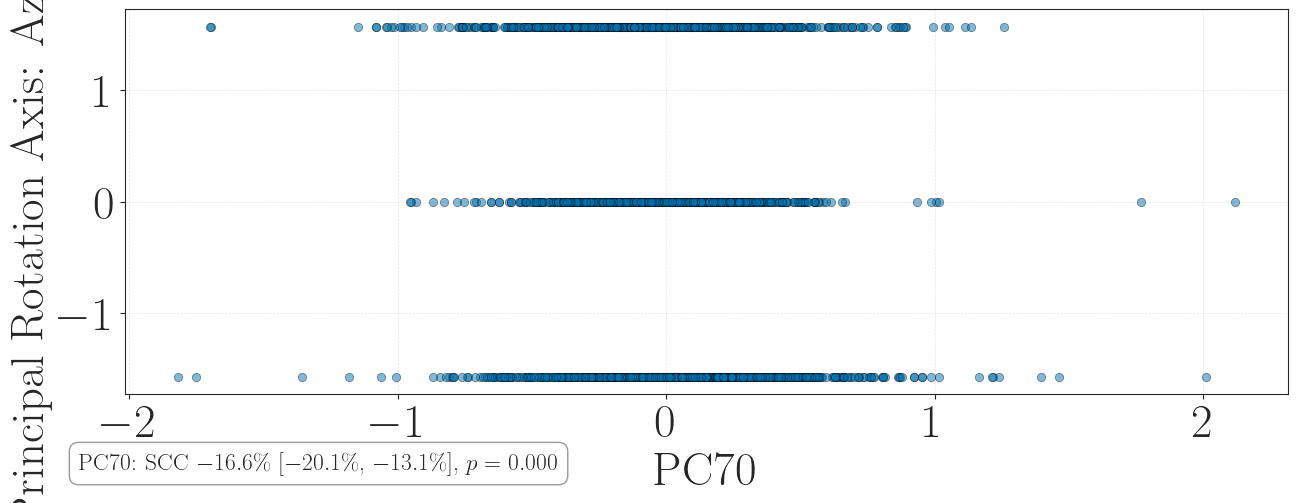

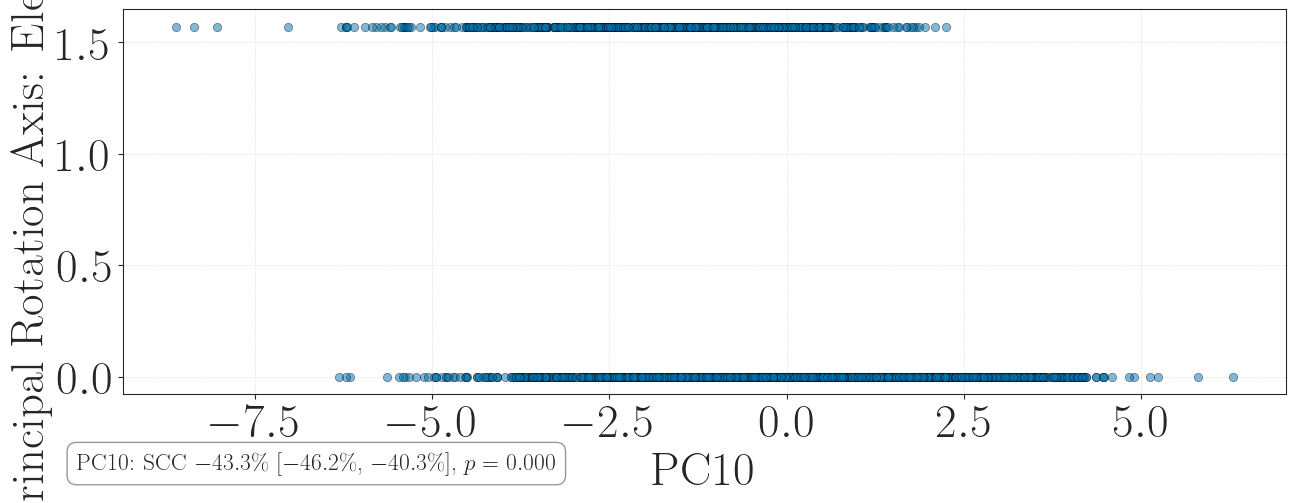

In [21]:
mat = transformation_matrix(morphs[:, 0, 0:1],
                            morphs[:, 0, 1:2],
                            morphs[:, 0, 2:3],
                            torch.zeros_like(morphs[:, 0, 0:1]))
torus_axis = torch.nn.functional.normalize(mat[:, :3, 2], dim=1)
x, y, z = torus_axis[:, 0], torus_axis[:, 1], torus_axis[:, 2]
azimuth   = torch.atan2(y, x)
elevation = torch.atan2(z, torch.sqrt(x**2 + y**2))

scalar_individual(full_latent, azimuth, "Principal Rotation Axis: Azimuth")
scalar_individual(full_latent, elevation, "Principal Rotation Axis: Elevation")

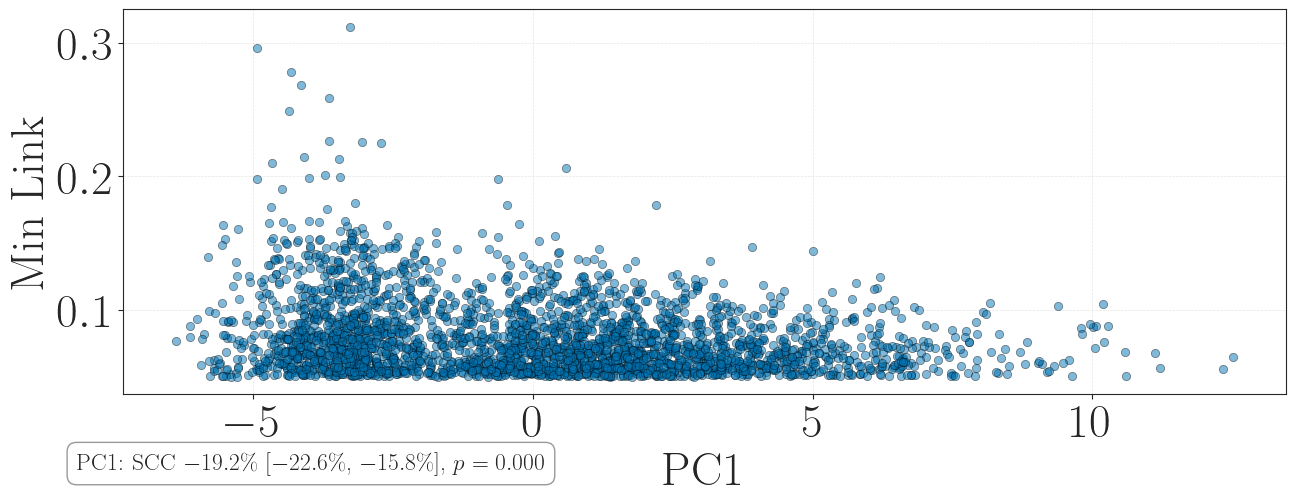

In [22]:
link_lengths = torch.hypot(morphs[:, :, 1], morphs[:, :, 2])
mask = (link_lengths != 0).int()
shortest_link = torch.min(link_lengths.abs() - mask, dim=1).values + 1
scalar_individual(full_latent, shortest_link, "Min Link")

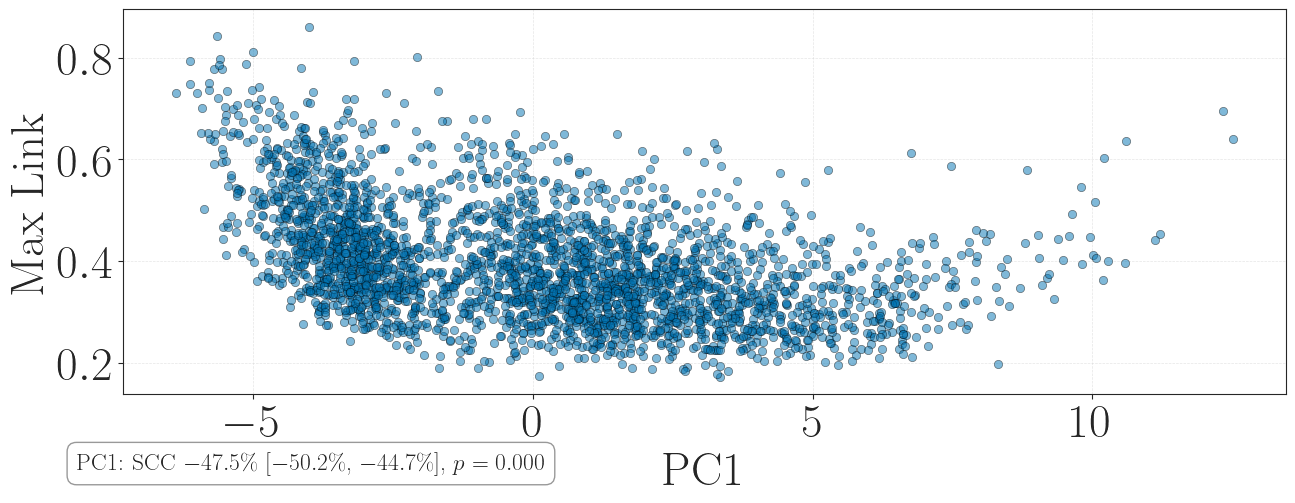

In [23]:
longest_link = torch.max(link_lengths.abs(), dim=1).values
scalar_individual(full_latent, longest_link, "Max Link")

PC1:  SCC $-58.2$\% $[-60.5$\%, $-55.7$\%], $p=0.000$


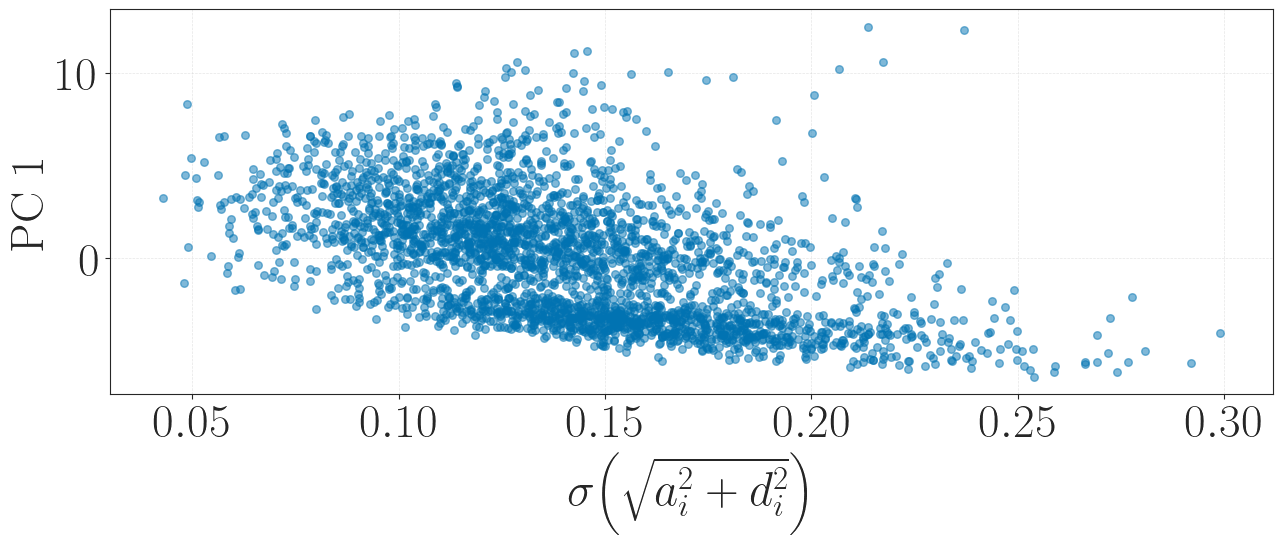

In [69]:
std_link = torch.std(link_lengths.abs(), dim=1)
scalar_individual(full_latent, std_link, r"$\sigma\!\left(\sqrt{a_i^2+d_i^2}\right)$")

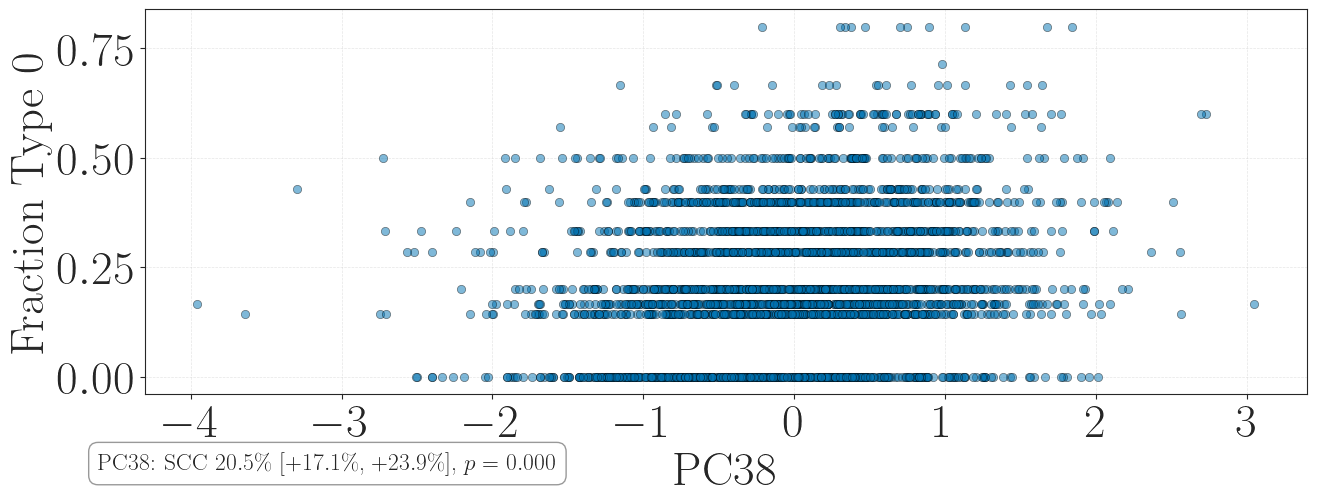

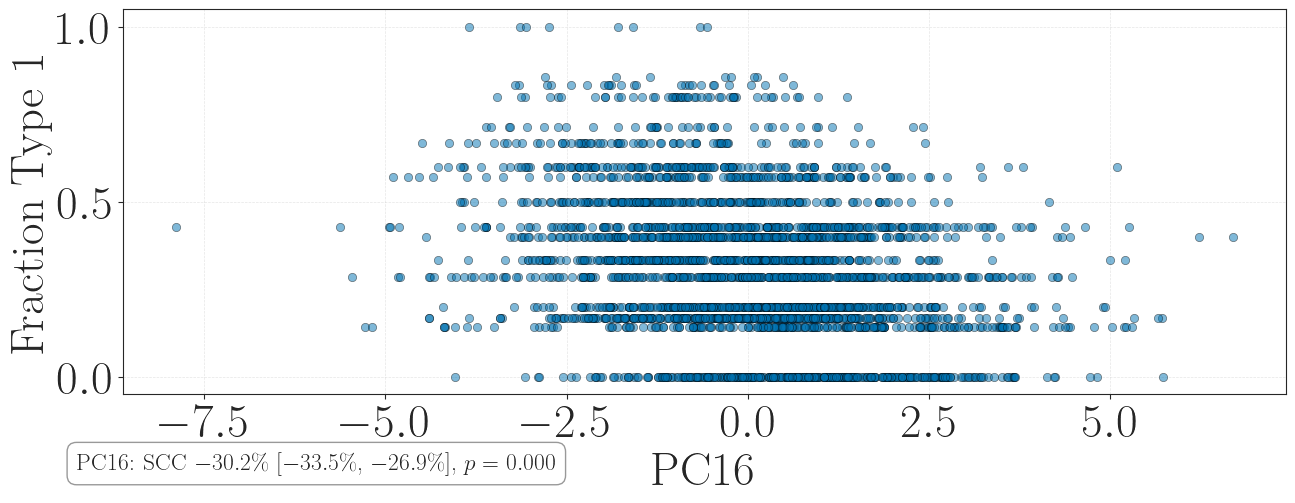

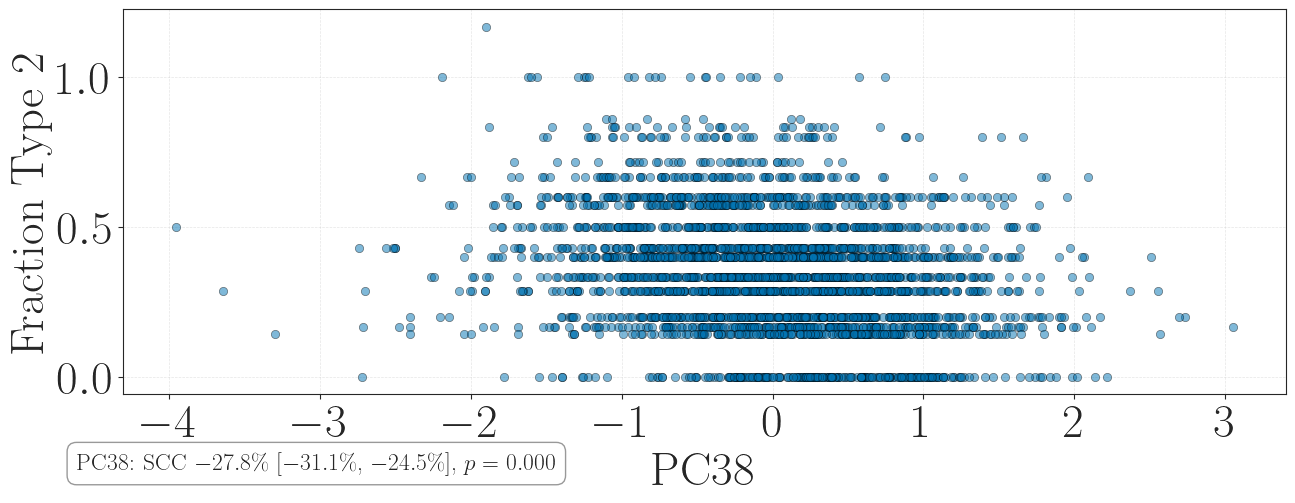

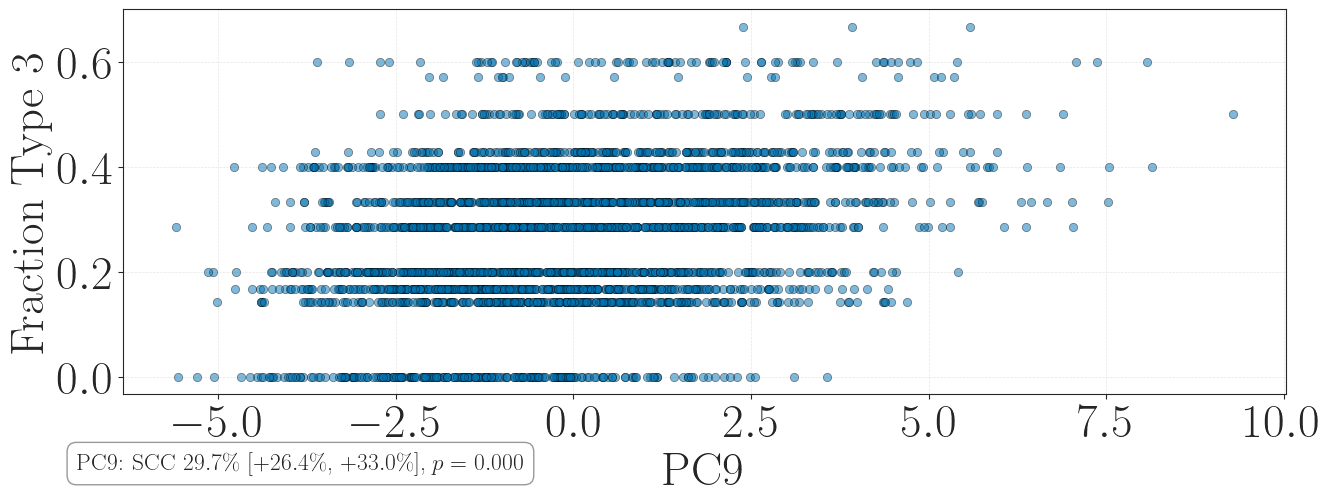

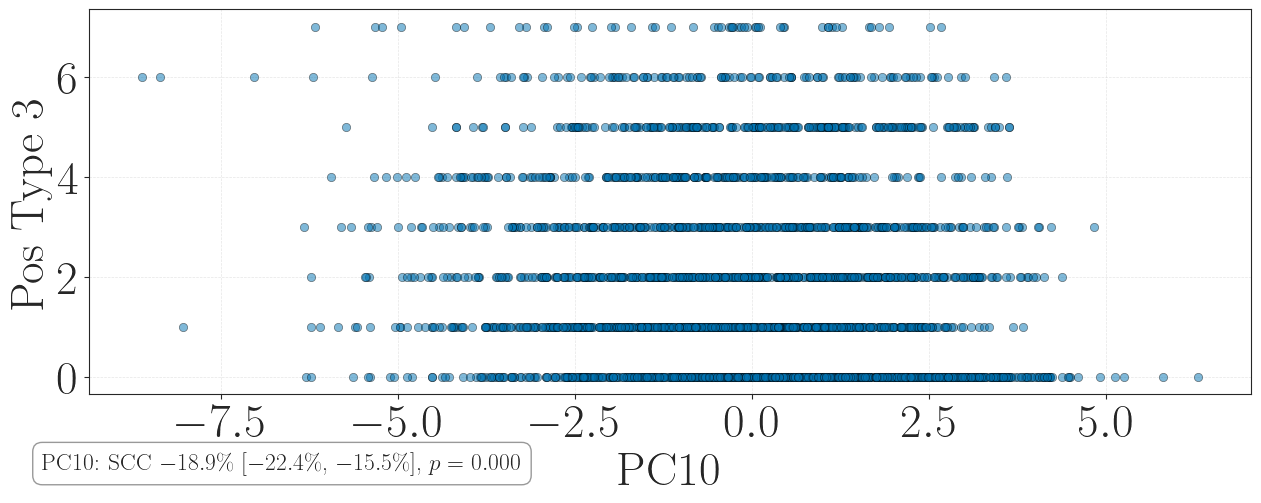

In [25]:
a = morphs[:, :, 1]
d = morphs[:, :, 2]
real_mask = (morphs.abs().sum(dim=-1) > 0)

link_types = torch.zeros_like(a, dtype=torch.long)
link_types[(a == 0) & (d != 0)] = 1
link_types[(a != 0) & (d == 0)] = 2
link_types[(a == 0) & (d == 0)] = 3
link_types[~real_mask] = -1

dof = (7 - (link_types == -1).sum(dim=1))
fraction_type0 = (link_types == 0).sum(dim=1) / dof
fraction_type1 = (link_types == 1).sum(dim=1) / dof
fraction_type2 = (link_types == 2).sum(dim=1) / dof
fraction_type3 = (link_types == 3).sum(dim=1) / dof
pos3 = link_types.argmax(dim=1).float()

scalar_individual(full_latent, fraction_type0, "Fraction Type 0")
scalar_individual(full_latent, fraction_type1, "Fraction Type 1")
scalar_individual(full_latent, fraction_type2, "Fraction Type 2")
scalar_individual(full_latent, fraction_type3, "Fraction Type 3")
scalar_individual(full_latent, pos3, "Pos Type 3")

In [26]:
# Does the latent space encode:

# Scalar & Individual
# - DoF
# - Movable Length
# - MDH elements
# - Reachability


# Vector & Individual
# - Workspace Centre
#   - X/Y/Z/Mag
# - Principal Axis
#   - Azimuth/Elevation
# - Link Sizes
#   - AVG/VAR/MAX/MIN

# Categorical Vector & Individual
# - Joint Types

# Scalar & Pairwise
# - Workspace Similarity

# Matrix & Pairwise
# - MDH Similarity

In [27]:
morphs_pairs = torch.cat([
    torch.cat([sample_morph(50, 5, False, device=device), torch.zeros(50, 2, 3, device=device)], dim=1),
    torch.cat([sample_morph(50, 6, False, device=device), torch.zeros(50, 1, 3, device=device)], dim=1),
    sample_morph(50, 7, False, device=device)
])

In [28]:
latent_pairs  = model.encoder(morphs_pairs)[1][0][-1].detach()

In [29]:
latent_dist = torch.cdist(latent_pairs, latent_pairs)

In [30]:
latent_normalised = torch.nn.functional.normalize(latent_pairs, dim=1)
cosine_similarity = latent_normalised @ latent_normalised.T

In [31]:
local_poses = torch.stack([
    sample_poses_in_reach(1000, m) for m in morphs_pairs
])

self_reach =  torch.stack([
    inverse_kinematics(m, p)[1] != -1 for p,m in zip(local_poses, morphs_pairs)
])


workspace_similarity = torch.zeros((morphs_pairs.shape[0], morphs_pairs.shape[0]), device=device)
workspace_similarity.fill_diagonal_(1.0)

for i in tqdm(range(morphs_pairs.shape[0])):
    for j in range(i + 1, morphs_pairs.shape[0]):
        other_reach_i = inverse_kinematics(morphs_pairs[i], local_poses[j])[-1] != -1
        other_reach_j = inverse_kinematics(morphs_pairs[j], local_poses[i])[-1] != -1

        reach_i = torch.cat([self_reach[i], other_reach_i])
        reach_j = torch.cat([other_reach_j, self_reach[j]])

        intersection = (reach_i & reach_j).sum().float()
        union        = (reach_i | reach_j).sum().float()

        workspace_similarity[i, j] = intersection / (union + 1e-8)
        workspace_similarity[j, i] = workspace_similarity[i, j]

100%|﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿| 150/150 [1:40:16<00:00, 40.11s/it] 


SCC $+32.4$\% $[+24.7$\%, $+44.2$\%], $p=0.001$
SCC $+27.5$\% $[+19.6$\%, $+38.6$\%], $p=0.001$


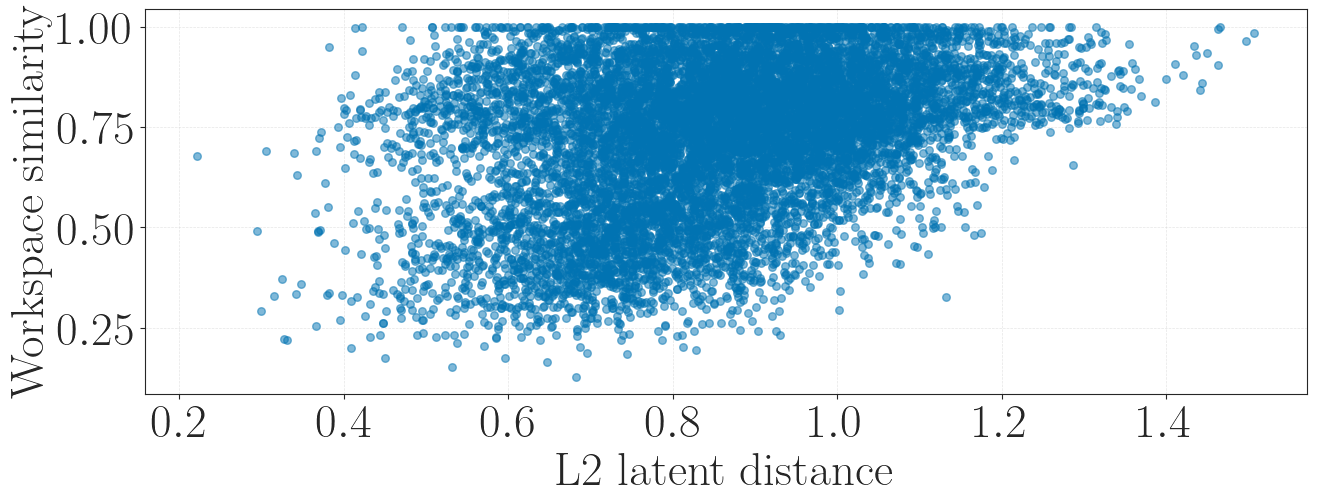

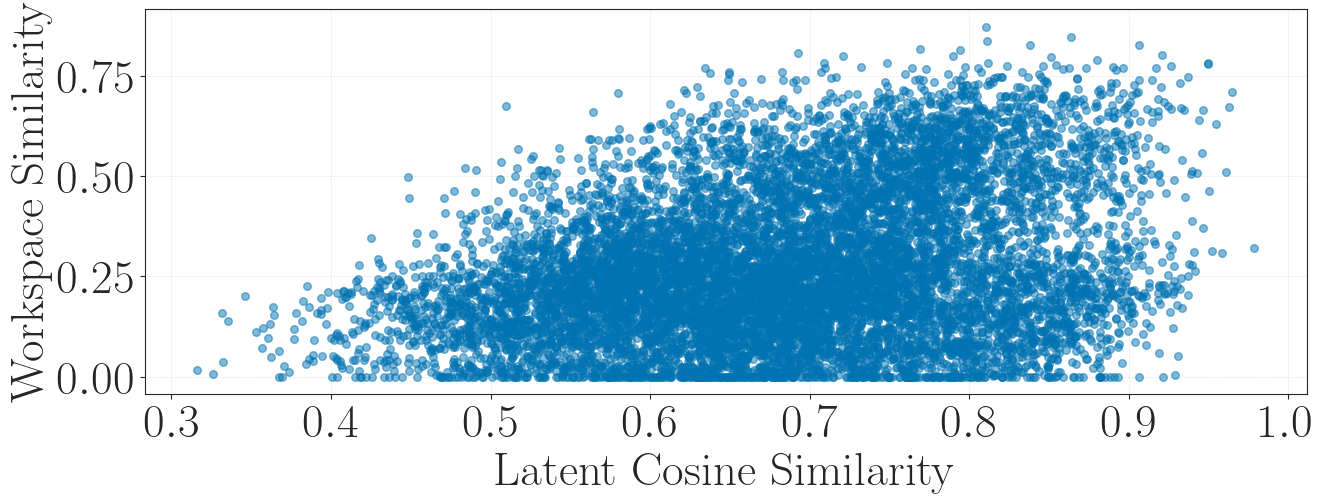

In [73]:
scalar_pairwise(latent_dist,   1 - workspace_similarity, "L2 latent distance", "Workspace similarity")
scalar_pairwise(cosine_similarity, workspace_similarity, "Latent Cosine Similarity", "Workspace Similarity")

SCC $+33.5$\% $[+25.1$\%, $+43.6$\%], $p=0.001$
SCC $+33.3$\% $[+25.3$\%, $+43.5$\%], $p=0.001$


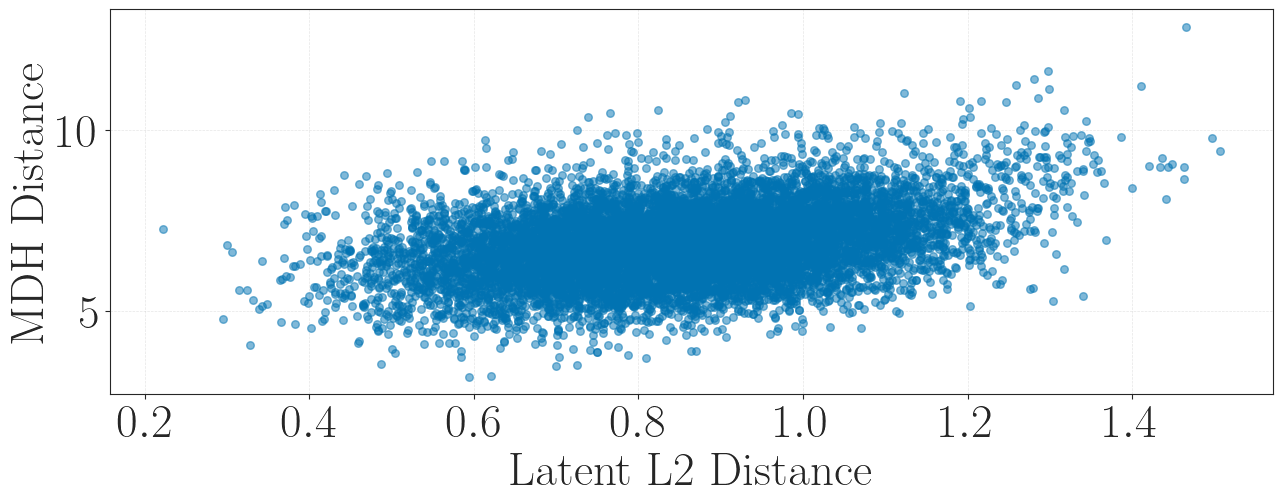

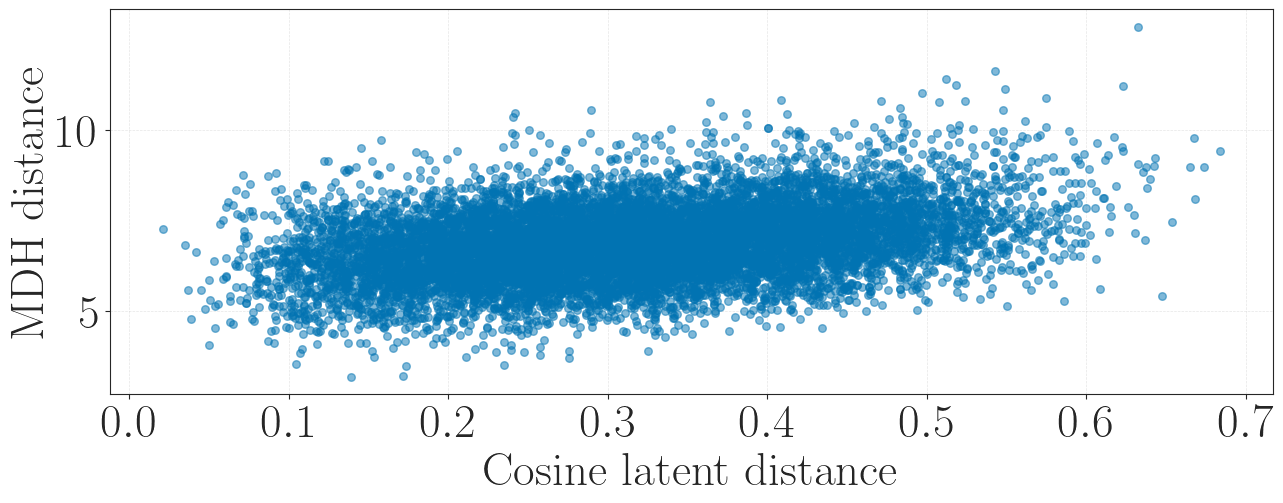

In [75]:
@jaxtyped(typechecker=beartype)
def mdh_distance_matrix(morphs: Float[Tensor, "n max_joints 3"]) -> Float[Tensor, "n n"]:
    """
    Pairwise distance matrix between MDH parameter matrices.
    Handles variable DoF via zero-padding and normalises each parameter column.

    Args:
        morphs: MDH parameters (alpha, a, d), padded to max_joints with zeros.
    Returns:
        Symmetric pairwise distance matrix.
    """
    n = morphs.shape[0]

    # Normalise each of the 3 parameter columns independently
    # to put alpha, a, d on comparable scales
    flat = morphs.reshape(n, -1)                                  # (n, max_joints*3)
    std  = flat.std(dim=0).clamp(min=1e-8)                        # (max_joints*3,)
    flat_normed = flat / std                                       # (n, max_joints*3)

    # Pairwise L2 distance on the flattened, normalised parameters
    dist = torch.cdist(flat_normed, flat_normed)                   # (n, n)
    return dist


# ── Usage ─────────────────────────────────────────────────────────────────────
mdh_dist      = mdh_distance_matrix(morphs_pairs)


scalar_pairwise(latent_dist,    mdh_dist, "Latent L2 Distance",     "MDH Distance")
scalar_pairwise(1 - cosine_similarity,  mdh_dist, "Cosine latent distance",  "MDH distance")